# 🧪 Prédiction de la Solubilité Moléculaire avec RDKit et Machine Learning

**Projet de Master en Intelligence Artificielle**

---

## Objectif

Ce notebook présente un pipeline complet de Machine Learning pour prédire la **solubilité aqueuse des molécules** (LogS) à partir de leur représentation **SMILES**, en utilisant le dataset **AqSolDB** (Curated Solubility Dataset).

L'approche combine :
- L'extraction de **descripteurs moléculaires** via RDKit
- Des **Morgan Fingerprints** (empreintes chimiques)
- Plusieurs modèles ML comparés : **Linear Regression, Random Forest, XGBoost, SVR**
- Des stratégies explicites de **lutte contre l'overfitting**

---

## Plan du notebook

1. Analyse exploratoire des données (EDA)
2. Nettoyage des données
3. Extraction des caractéristiques avec RDKit
4. Réduction du risque d'overfitting
5. Division Train/Test
6. Entraînement des modèles
7. Validation croisée
8. Optimisation des hyperparamètres
9. Évaluation finale
10. Détection automatique de l'overfitting
11. Visualisations
12. Choix du meilleur modèle

---

## 0. Importation des librairies

In [5]:
!pip install rdkit

In [6]:
# ── Librairies standard ──────────────────────────────────────────────────────
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

# ── RDKit ────────────────────────────────────────────────────────────────────
from rdkit import Chem
from rdkit.Chem import Descriptors, rdMolDescriptors, QED, AllChem
from rdkit.Chem.rdMolDescriptors import GetMorganFingerprintAsBitVect

# ── Scikit-learn ─────────────────────────────────────────────────────────────
from sklearn.model_selection import (
    train_test_split, KFold, cross_val_score, RandomizedSearchCV
)
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_regression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.pipeline import Pipeline

# ── XGBoost ───────────────────────────────────────────────────────────────────
import xgboost as xgb
from xgboost import XGBRegressor

# ── Configuration générale ────────────────────────────────────────────────────
warnings.filterwarnings('ignore')
np.random.seed(42)

# Style global des graphiques
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.titlesize'] = 13

RANDOM_STATE = 42
print('✅ Toutes les librairies importées avec succès.')

✅ Toutes les librairies importées avec succès.


---
## 1. Analyse Exploratoire des Données (EDA)

In [7]:
# ── 1.1 Chargement du dataset ─────────────────────────────────────────────────
# Adapter le chemin selon votre environnement
CSV_PATH = '/content/curated-solubility-dataset.csv'

df_raw = pd.read_csv(CSV_PATH)

print('=' * 55)
print('       APERÇU DU DATASET AqSolDB')
print('=' * 55)
print(f'\n📐 Dimensions : {df_raw.shape[0]:,} lignes × {df_raw.shape[1]} colonnes\n')
df_raw.head(3)

       APERÇU DU DATASET AqSolDB

📐 Dimensions : 9,982 lignes × 26 colonnes



,ID,Name,InChI,InChIKey,SMILES,Solubility,SD,Ocurrences,Group,MolWt,...,NumRotatableBonds,NumValenceElectrons,NumAromaticRings,NumSaturatedRings,NumAliphaticRings,RingCount,TPSA,LabuteASA,BalabanJ,BertzCT
0,A-3,"N,N,N-trimethyloctadecan-1-aminium bromide",InChI=1S/C21H46N.BrH/c1-5-6-7-8-9-10-11-12-13-...,SZEMGTQCPRNXEG-UHFFFAOYSA-M,[Br-].CCCCCCCCCCCCCCCCCC[N+](C)(C)C,-3.616127,0.0,1,G1,392.510,...,17.0,142.0,0.0,0.0,0.0,0.0,0.00,158.520601,0.000000,210.377334
1,A-4,Benzo[cd]indol-2(1H)-one,InChI=1S/C11H7NO/c13-11-8-5-1-3-7-4-2-6-9(12-1...,GPYLCFQEKPUWLD-UHFFFAOYSA-N,O=C1Nc2cccc3cccc1c23,-3.254767,0.0,1,G1,169.183,...,0.0,62.0,2.0,0.0,1.0,3.0,29.10,75.183563,2.582996,511.229248
2,A-5,4-chlorobenzaldehyde,InChI=1S/C7H5ClO/c8-7-3-1-6(5-9)2-4-7/h1-5H,AVPYQKSLYISFPO-UHFFFAOYSA-N,Clc1ccc(C=O)cc1,-2.177078,0.0,1,G1,140.569,...,1.0,46.0,1.0,0.0,0.0,1.0,17.07,58.261134,3.009782,202.661065


In [8]:
# ── 1.2 Types des colonnes ─────────────────────────────────────────────────────
print('📋 Types des colonnes :')
print(df_raw.dtypes.to_string())

📋 Types des colonnes :
ID                      object
Name                    object
InChI                   object
InChIKey                object
SMILES                  object
Solubility             float64
SD                     float64
Ocurrences               int64
Group                   object
MolWt                  float64
MolLogP                float64
MolMR                  float64
HeavyAtomCount         float64
NumHAcceptors          float64
NumHDonors             float64
NumHeteroatoms         float64
NumRotatableBonds      float64
NumValenceElectrons    float64
NumAromaticRings       float64
NumSaturatedRings      float64
NumAliphaticRings      float64
RingCount              float64
TPSA                   float64
LabuteASA              float64
BalabanJ               float64
BertzCT                float64


In [9]:
# ── 1.3 Valeurs manquantes ─────────────────────────────────────────────────────
missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(2)
missing_df = pd.DataFrame({'Manquantes': missing, '% Manquantes': missing_pct})
print('🔍 Valeurs manquantes par colonne :')
print(missing_df[missing_df['Manquantes'] > 0] if missing_df['Manquantes'].sum() > 0
      else '✅ Aucune valeur manquante dans le dataset.')

🔍 Valeurs manquantes par colonne :
✅ Aucune valeur manquante dans le dataset.


In [10]:
# ── 1.4 Statistiques descriptives de la variable cible ────────────────────────
print('📊 Statistiques descriptives – Solubility (LogS) :')
print(df_raw['Solubility'].describe().round(4).to_string())
print(f'\n  Asymétrie (skewness) : {df_raw["Solubility"].skew():.4f}')
print(f'  Aplatissement (kurtosis) : {df_raw["Solubility"].kurt():.4f}')

📊 Statistiques descriptives – Solubility (LogS) :
count    9982.0000
mean       -2.8899
std         2.3682
min       -13.1719
25%        -4.3263
50%        -2.6182
75%        -1.2097
max         2.1377

  Asymétrie (skewness) : -0.5517
  Aplatissement (kurtosis) : -0.0594


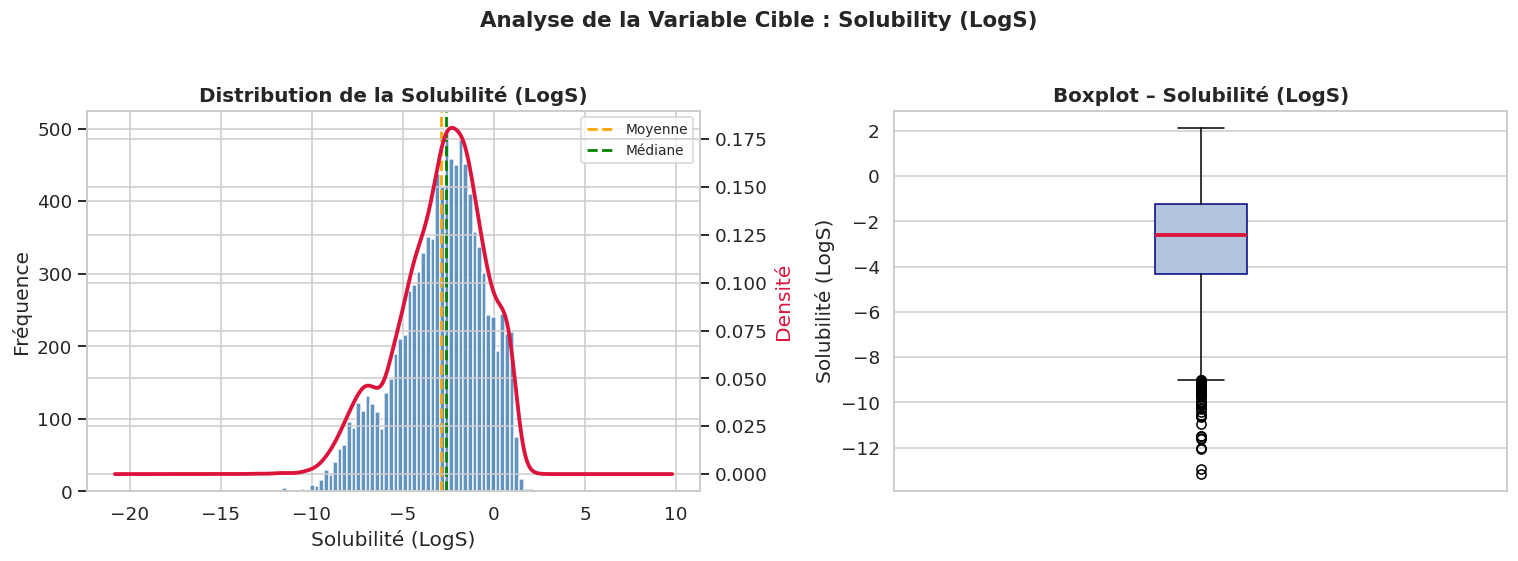

📌 Remarque : La distribution est proche d'une loi normale légèrement asymétrique, avec une queue sur les valeurs très négatives (molécules très peu solubles).


In [11]:
# ── 1.5 Distribution de la variable cible ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogramme + KDE
axes[0].hist(df_raw['Solubility'], bins=60, color='steelblue',
             edgecolor='white', alpha=0.85)
ax2 = axes[0].twinx()
df_raw['Solubility'].plot.kde(ax=ax2, color='crimson', linewidth=2.5)
ax2.set_ylabel('Densité', color='crimson')
axes[0].set_xlabel('Solubilité (LogS)')
axes[0].set_ylabel('Fréquence')
axes[0].set_title('Distribution de la Solubilité (LogS)')
# Lignes de référence
for val, lbl, col in [(df_raw['Solubility'].mean(), 'Moyenne', 'orange'),
                      (df_raw['Solubility'].median(), 'Médiane', 'green')]:
    axes[0].axvline(val, color=col, linestyle='--', linewidth=1.8, label=lbl)
axes[0].legend(fontsize=9)

# Boxplot
axes[1].boxplot(df_raw['Solubility'].dropna(), vert=True,
                patch_artist=True,
                boxprops=dict(facecolor='lightsteelblue', color='navy'),
                medianprops=dict(color='crimson', linewidth=2.5))
axes[1].set_ylabel('Solubilité (LogS)')
axes[1].set_title('Boxplot – Solubilité (LogS)')
axes[1].set_xticks([])

plt.suptitle('Analyse de la Variable Cible : Solubility (LogS)', fontsize=14,
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig1_distribution_solubility.png', bbox_inches='tight', dpi=150)
plt.show()
print('📌 Remarque : La distribution est proche d\'une loi normale légèrement asymétrique,'
      ' avec une queue sur les valeurs très négatives (molécules très peu solubles).')

---
## 2. Nettoyage des Données

In [12]:
# ── 2.1 Suppression des colonnes non pertinentes ───────────────────────────────
cols_to_drop = ['ID', 'Name', 'InChI', 'InChIKey',
                'SD', 'Ocurrences', 'Group', 'MolWt', 'MolLogP',
                'MolMR', 'HeavyAtomCount', 'NumHAcceptors', 'NumHDonors',
                'NumHeteroatoms', 'NumRotatableBonds', 'NumValenceElectrons',
                'NumAromaticRings', 'NumSaturatedRings', 'NumAliphaticRings',
                'RingCount', 'TPSA', 'LabuteASA', 'BalabanJ', 'BertzCT']

# On ne conserve que SMILES + Solubility
df = df_raw[['SMILES', 'Solubility']].copy()
print(f'✅ Dataset après sélection des colonnes : {df.shape}')

# ── 2.2 Suppression des SMILES invalides ──────────────────────────────────────
def is_valid_smiles(smi):
    """Retourne True si le SMILES peut être parsé par RDKit."""
    if not isinstance(smi, str) or smi.strip() == '':
        return False
    mol = Chem.MolFromSmiles(smi)
    return mol is not None

valid_mask = df['SMILES'].apply(is_valid_smiles)
n_invalid  = (~valid_mask).sum()
df = df[valid_mask].reset_index(drop=True)

print(f'🗑️  Molécules avec SMILES invalides supprimées : {n_invalid}')
print(f'✅ Dataset final : {df.shape[0]:,} molécules valides')

✅ Dataset après sélection des colonnes : (9982, 2)


[11:15:19] WARNING: not removing hydrogen atom without neighbors
[11:15:19] WARNING: not removing hydrogen atom without neighbors
[11:15:19] WARNING: not removing hydrogen atom without neighbors
[11:15:19] WARNING: not removing hydrogen atom without neighbors
[11:15:19] WARNING: not removing hydrogen atom without neighbors
[11:15:19] WARNING: not removing hydrogen atom without neighbors
[11:15:19] WARNING: not removing hydrogen atom without neighbors
[11:15:19] WARNING: not removing hydrogen atom without neighbors
[11:15:19] WARNING: not removing hydrogen atom without neighbors
[11:15:19] WARNING: not removing hydrogen atom without neighbors
[11:15:19] WARNING: not removing hydrogen atom without neighbors
[11:15:19] WARNING: not removing hydrogen atom without neighbors
[11:15:19] WARNING: not removing hydrogen atom without neighbors
[11:15:19] WARNING: not removing hydrogen atom without neighbors
[11:15:19] WARNING: not removing hydrogen atom without neighbors
[11:15:19] WARNING: not r

🗑️  Molécules avec SMILES invalides supprimées : 2
✅ Dataset final : 9,980 molécules valides


---
## 3. Extraction des Caractéristiques avec RDKit

Nous calculons **10 descripteurs physicochimiques** et **256 bits de Morgan Fingerprints** (radius=2).


In [13]:
# ── 3.1 Fonction de calcul des descripteurs moléculaires ──────────────────────
def compute_descriptors(smiles: str) -> dict | None:
    """
    Calcule 10 descripteurs RDKit + 64 bits Morgan Fingerprints.
    Retourne None si le SMILES est invalide.
    """
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None

    # ── 10 Descripteurs physicochimiques ───────────────────────────────────────
    desc = {
        'MolWt'            : Descriptors.MolWt(mol),
        'MolLogP'          : Descriptors.MolLogP(mol),
        'TPSA'             : Descriptors.TPSA(mol),
        'NumHDonors'       : rdMolDescriptors.CalcNumHBD(mol),
        'NumHAcceptors'    : rdMolDescriptors.CalcNumHBA(mol),
        'NumRotatableBonds': rdMolDescriptors.CalcNumRotatableBonds(mol),
        'NumAromaticRings' : rdMolDescriptors.CalcNumAromaticRings(mol),
        'FractionCSP3'     : rdMolDescriptors.CalcFractionCSP3(mol),
        'HeavyAtomCount'   : mol.GetNumHeavyAtoms(),
        'QED'              : QED.qed(mol),
    }

    # ── Morgan Fingerprints (radius=2, 64 bits) ────────────────────────────────
    fp = GetMorganFingerprintAsBitVect(mol, radius=2, nBits=256)
    fp_dict = {f'fp_{i}': int(fp[i]) for i in range(256)}

    return {**desc, **fp_dict}


# ── 3.2 Application sur toutes les molécules ───────────────────────────────────
print('⏳ Calcul des descripteurs moléculaires...')
features_list = [compute_descriptors(smi) for smi in df['SMILES']]

# Suppression des None résiduels (sécurité)
valid_idx = [i for i, f in enumerate(features_list) if f is not None]
df          = df.iloc[valid_idx].reset_index(drop=True)
features_list = [f for f in features_list if f is not None]

X_raw = pd.DataFrame(features_list)
y     = df['Solubility'].values

print(f'✅ Matrice de features : {X_raw.shape}')
print(f'   → {10} descripteurs RDKit + 64 Morgan Fingerprints = {X_raw.shape[1]} features total')
print(f'\n🔎 Aperçu des 5 premières features :')
X_raw.iloc[:3, :5]

⏳ Calcul des descripteurs moléculaires...


Le flux de sortie a été tronqué et ne contient que les 5000 dernières lignes.
[11:15:43] DEPRECATION WARNING: please use MorganGenerator
[11:15:43] DEPRECATION WARNING: please use MorganGenerator
[11:15:43] DEPRECATION WARNING: please use MorganGenerator
[11:15:43] DEPRECATION WARNING: please use MorganGenerator
[11:15:43] DEPRECATION WARNING: please use MorganGenerator
[11:15:43] DEPRECATION WARNING: please use MorganGenerator
[11:15:43] DEPRECATION WARNING: please use MorganGenerator
[11:15:43] DEPRECATION WARNING: please use MorganGenerator
[11:15:43] DEPRECATION WARNING: please use MorganGenerator
[11:15:43] DEPRECATION WARNING: please use MorganGenerator
[11:15:43] DEPRECATION WARNING: please use MorganGenerator
[11:15:43] DEPRECATION WARNING: please use MorganGenerator
[11:15:43] DEPRECATION WARNING: please use MorganGenerator
[11:15:43] DEPRECATION WARNING: please use MorganGenerator
[11:15:43] DEPRECATION WARNING: please use MorganGenerator
[11:15:43] DEPRECATION WARNING: pleas

✅ Matrice de features : (9980, 266)
   → 10 descripteurs RDKit + 64 Morgan Fingerprints = 266 features total

🔎 Aperçu des 5 premières features :


,MolWt,MolLogP,TPSA,NumHDonors,NumHAcceptors
0,392.510,3.9581,0.00,0,0
1,169.183,2.4055,29.10,1,1
2,140.569,2.1525,17.07,0,1


In [14]:
# ── 3.3 Statistiques de la matrice de features ────────────────────────────────
print('📊 Statistiques des descripteurs moléculaires (10 premières features) :')
X_raw.iloc[:, :10].describe().round(3)

📊 Statistiques des descripteurs moléculaires (10 premières features) :


,MolWt,MolLogP,TPSA,NumHDonors,NumHAcceptors,NumRotatableBonds,NumAromaticRings,FractionCSP3,HeavyAtomCount,QED
count,9980.000,9980.000,9980.000,9980.000,9980.000,9980.000,9980.000,9980.000,9980.000,9980.000
mean,266.694,1.980,62.458,1.109,3.414,4.074,1.066,0.427,17.376,0.524
std,184.186,3.519,63.353,1.489,3.459,5.647,1.299,0.353,12.242,0.193
min,9.012,-40.873,0.000,0.000,0.000,0.000,0.000,0.000,1.000,0.007
25%,162.276,0.620,26.300,0.000,2.000,1.000,0.000,0.103,11.000,0.403
50%,228.682,1.950,50.720,1.000,3.000,3.000,1.000,0.364,15.000,0.534
75%,320.533,3.423,80.390,2.000,4.000,5.000,2.000,0.750,21.000,0.661
max,5299.456,68.541,1214.340,26.000,86.000,141.000,35.000,1.000,388.000,0.943


---
## 4. Réduction du Risque d'Overfitting

Nous appliquons **3 étapes de filtrage** des features avant l'entraînement :

| Étape | Méthode | Objectif |
|-------|---------|----------|
| 1 | VarianceThreshold | Éliminer les features constantes |
| 2 | Corrélation > 0.95 | Réduire la redondance d'information |
| 3 | SelectKBest (f_regression) | Garder les features les plus informatives |

In [15]:
# ── 4.1 Suppression des features constantes ───────────────────────────────────
vt = VarianceThreshold(threshold=0.0)
vt.fit(X_raw)
cols_after_vt = X_raw.columns[vt.get_support()]
X_var = X_raw[cols_after_vt].copy()
n_removed_vt = X_raw.shape[1] - X_var.shape[1]
print(f'1️⃣  Features constantes supprimées : {n_removed_vt}')
print(f'   Features restantes : {X_var.shape[1]}')

# ── 4.2 Suppression des features fortement corrélées (> 0.95) ──────────────────
corr_matrix = X_var.corr().abs()
upper_tri   = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)
to_drop_corr = [col for col in upper_tri.columns
                if any(upper_tri[col] > 0.95)]
X_filtered = X_var.drop(columns=to_drop_corr)
print(f'\n2️⃣  Features corrélées (r > 0.95) supprimées : {len(to_drop_corr)}')
if to_drop_corr:
    print(f'   Colonnes : {to_drop_corr}')
print(f'   Features restantes : {X_filtered.shape[1]}')

# ── 4.3 SelectKBest – sélection des K meilleures features ─────────────────────
# On choisit K = min(50, nb_features_restantes) pour conserver l'essentiel
K_BEST = min(50, X_filtered.shape[1])
selector = SelectKBest(score_func=f_regression, k=K_BEST)
X_selected = selector.fit_transform(X_filtered, y)
selected_feature_names = X_filtered.columns[selector.get_support()].tolist()

print(f'\n3️⃣  SelectKBest (k={K_BEST}) : features sélectionnées = {X_selected.shape[1]}')
print(f'\n✅ Matrice finale : {X_selected.shape[0]:,} échantillons × {X_selected.shape[1]} features')
print(f'   (Réduction : {X_raw.shape[1]} → {X_selected.shape[1]} features)')

1️⃣  Features constantes supprimées : 0
   Features restantes : 266

2️⃣  Features corrélées (r > 0.95) supprimées : 1
   Colonnes : ['HeavyAtomCount']
   Features restantes : 265

3️⃣  SelectKBest (k=50) : features sélectionnées = 50

✅ Matrice finale : 9,980 échantillons × 50 features
   (Réduction : 266 → 50 features)


---
## 5. Division des Données (Train / Test)

In [16]:
# ── 5.1 Split 80 / 20 ─────────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y, test_size=0.20, random_state=RANDOM_STATE
)

print('=' * 40)
print('    Division Train / Test')
print('=' * 40)
print(f'  Train : {X_train.shape[0]:,} échantillons ({X_train.shape[0]/len(y)*100:.1f}%)')
print(f'  Test  : {X_test.shape[0]:,} échantillons ({X_test.shape[0]/len(y)*100:.1f}%)')
print(f'  Features : {X_train.shape[1]}')

# ── 5.2 Standardisation pour SVR (uniquement) ─────────────────────────────────
scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)
print('\n✅ Données standardisées (pour SVR) prêtes.')

    Division Train / Test
  Train : 7,984 échantillons (80.0%)
  Test  : 1,996 échantillons (20.0%)
  Features : 50

✅ Données standardisées (pour SVR) prêtes.


---
## 6. Entraînement des Modèles

Quatre modèles sont comparés, avec des hyperparamètres choisis pour **limiter l'overfitting** :
- **Linear Regression** : modèle de référence (baseline)
- **Random Forest** : ensemble d'arbres, avec profondeur et taille minimale contraintes
- **XGBoost** : gradient boosting avec régularisation
- **SVR** : Support Vector Regression avec kernel RBF

In [17]:
# ── 6.1 Définition des modèles ────────────────────────────────────────────────
models = {
    'Linear Regression': LinearRegression(),

    'Random Forest': RandomForestRegressor(
        n_estimators=200,
        max_depth=10,
        min_samples_split=10,
        min_samples_leaf=5,
        max_features='sqrt',
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),

    'XGBoost': XGBRegressor(
        n_estimators=300,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.7,
        reg_alpha=0.1,          # Régularisation L1
        reg_lambda=1.0,         # Régularisation L2
        min_child_weight=5,     # Contrainte sur la taille des feuilles
        random_state=RANDOM_STATE,
        verbosity=0
    ),

    'SVR': SVR(
        kernel='rbf',
        C=10,
        epsilon=0.1,
        gamma='scale'
    ),
}

# ── 6.2 Entraînement de tous les modèles ──────────────────────────────────────
fitted_models = {}

for name, model in models.items():
    if name == 'SVR':
        model.fit(X_train_sc, y_train)
    else:
        model.fit(X_train, y_train)
    fitted_models[name] = model
    print(f'✅ {name} : entraîné.')

print('\n🎉 Tous les modèles ont été entraînés.')

✅ Linear Regression : entraîné.
✅ Random Forest : entraîné.
✅ XGBoost : entraîné.
✅ SVR : entraîné.

🎉 Tous les modèles ont été entraînés.


---
## 7. Validation Croisée (KFold, k=5)

La validation croisée permet d'évaluer la **capacité de généralisation** des modèles, indépendamment du split train/test.

In [18]:
# ── 7.1 Validation croisée sur le train set ───────────────────────────────────
kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_results = {}
print('⏳ Validation croisée (KFold k=5)...\n')

for name, model in models.items():
    if name == 'SVR':
        X_cv = X_train_sc
    else:
        X_cv = X_train

    scores = cross_val_score(model, X_cv, y_train,
                             cv=kf, scoring='r2', n_jobs=-1)
    cv_results[name] = {'mean_r2': scores.mean(), 'std_r2': scores.std(), 'scores': scores}

    print(f'  {name:<22}  R² = {scores.mean():.4f} ± {scores.std():.4f}')
    print(f'  {"":>22}  Scores : {[round(s,4) for s in scores]}')

print('\n✅ Validation croisée terminée.')

⏳ Validation croisée (KFold k=5)...

  Linear Regression       R² = 0.5265 ± 0.0264
                          Scores : [np.float64(0.5276), np.float64(0.5621), np.float64(0.487), np.float64(0.5462), np.float64(0.5097)]
  Random Forest           R² = 0.7090 ± 0.0135
                          Scores : [np.float64(0.7088), np.float64(0.7205), np.float64(0.7271), np.float64(0.6972), np.float64(0.6914)]
  XGBoost                 R² = 0.7642 ± 0.0203
                          Scores : [np.float64(0.7622), np.float64(0.7862), np.float64(0.7885), np.float64(0.7426), np.float64(0.7414)]
  SVR                     R² = 0.7129 ± 0.0212
                          Scores : [np.float64(0.7088), np.float64(0.7318), np.float64(0.7407), np.float64(0.7016), np.float64(0.6817)]

✅ Validation croisée terminée.


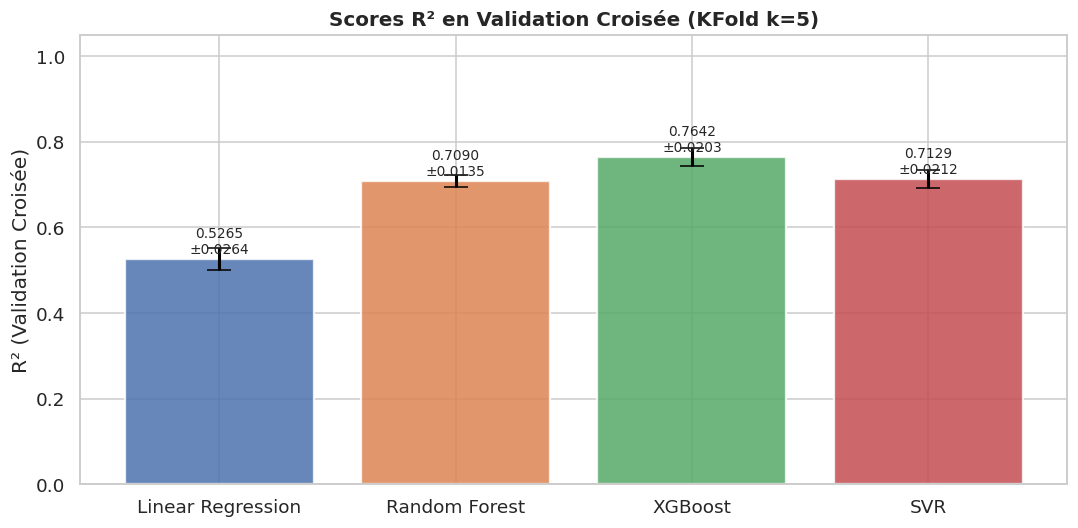

In [19]:
# ── 7.2 Visualisation des scores CV ───────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

names_cv  = list(cv_results.keys())
means_cv  = [cv_results[n]['mean_r2'] for n in names_cv]
stds_cv   = [cv_results[n]['std_r2']  for n in names_cv]
colors_cv = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

bars = ax.bar(names_cv, means_cv, color=colors_cv, alpha=0.85,
              edgecolor='white', linewidth=1.5)
ax.errorbar(names_cv, means_cv, yerr=stds_cv, fmt='none',
            color='black', capsize=8, linewidth=2)

for bar, m, s in zip(bars, means_cv, stds_cv):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.005,
            f'{m:.4f}\n±{s:.4f}', ha='center', va='bottom', fontsize=9)

ax.set_ylim(0, 1.05)
ax.set_ylabel('R² (Validation Croisée)')
ax.set_title('Scores R² en Validation Croisée (KFold k=5)')
plt.tight_layout()
plt.savefig('fig2_cv_scores.png', bbox_inches='tight', dpi=150)
plt.show()

---
## 8. Optimisation des Hyperparamètres (RandomizedSearchCV)

On optimise uniquement **Random Forest** et **XGBoost**, les modèles les plus sensibles aux hyperparamètres.
L'objectif est d'améliorer la **généralisation sur le test**, pas de maximiser le score sur le train.

In [20]:
# ── 8.1 Optimisation Random Forest ────────────────────────────────────────────
rf_param_grid = {
    'n_estimators'    : [100, 200, 300, 500],
    'max_depth'       : [5, 8, 10, 12, None],
    'min_samples_split': [5, 10, 15, 20],
    'min_samples_leaf': [3, 5, 8, 10],
    'max_features'    : ['sqrt', 'log2', 0.5],
}

rf_search = RandomizedSearchCV(
    RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1),
    param_distributions=rf_param_grid,
    n_iter=30,
    cv=KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    scoring='r2',
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1
)

print('⏳ Optimisation Random Forest (30 itérations × 5 folds)...')
rf_search.fit(X_train, y_train)
print(f'\n✅ Meilleurs paramètres RF   : {rf_search.best_params_}')
print(f'   Meilleur R² CV           : {rf_search.best_score_:.4f}')

best_rf = rf_search.best_estimator_

⏳ Optimisation Random Forest (30 itérations × 5 folds)...
Fitting 5 folds for each of 30 candidates, totalling 150 fits

✅ Meilleurs paramètres RF   : {'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 5, 'max_features': 0.5, 'max_depth': None}
   Meilleur R² CV           : 0.7605


In [21]:
# ── 8.2 Optimisation XGBoost ──────────────────────────────────────────────────
xgb_param_grid = {
    'n_estimators'    : [200, 300, 500],
    'max_depth'       : [3, 4, 5, 6],
    'learning_rate'   : [0.01, 0.03, 0.05, 0.1],
    'subsample'       : [0.6, 0.7, 0.8, 0.9],
    'colsample_bytree': [0.6, 0.7, 0.8],
    'reg_alpha'       : [0.0, 0.01, 0.1, 0.5],
    'reg_lambda'      : [0.5, 1.0, 2.0, 5.0],
    'min_child_weight': [3, 5, 7, 10],
}

xgb_search = RandomizedSearchCV(
    XGBRegressor(random_state=RANDOM_STATE, verbosity=0),
    param_distributions=xgb_param_grid,
    n_iter=30,
    cv=KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    scoring='r2',
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1
)

print('⏳ Optimisation XGBoost (30 itérations × 5 folds)...')
xgb_search.fit(X_train, y_train)
print(f'\n✅ Meilleurs paramètres XGBoost : {xgb_search.best_params_}')
print(f'   Meilleur R² CV              : {xgb_search.best_score_:.4f}')

best_xgb = xgb_search.best_estimator_

⏳ Optimisation XGBoost (30 itérations × 5 folds)...
Fitting 5 folds for each of 30 candidates, totalling 150 fits

✅ Meilleurs paramètres XGBoost : {'subsample': 0.9, 'reg_lambda': 5.0, 'reg_alpha': 0.5, 'n_estimators': 500, 'min_child_weight': 10, 'max_depth': 6, 'learning_rate': 0.03, 'colsample_bytree': 0.7}
   Meilleur R² CV              : 0.7692


In [22]:
# ── 8.3 Remplacement par les modèles optimisés ────────────────────────────────
fitted_models['Random Forest'] = best_rf
fitted_models['XGBoost']       = best_xgb
print('✅ Modèles RF et XGBoost mis à jour avec les meilleurs hyperparamètres.')

✅ Modèles RF et XGBoost mis à jour avec les meilleurs hyperparamètres.


---
## 9. Évaluation Finale

Calcul des métriques sur l'ensemble d'entraînement **et** de test pour chaque modèle.

In [23]:
# ── 9.1 Fonction d'évaluation ─────────────────────────────────────────────────
def evaluate_model(model, X_tr, y_tr, X_te, y_te):
    """Retourne un dictionnaire de métriques train/test."""
    y_pred_tr = model.predict(X_tr)
    y_pred_te = model.predict(X_te)

    mse_tr  = mean_squared_error(y_tr, y_pred_tr)
    mse_te  = mean_squared_error(y_te, y_pred_te)

    return {
        'MSE_train' : mse_tr,
        'MSE_test'  : mse_te,
        'RMSE_train': np.sqrt(mse_tr),
        'RMSE_test' : np.sqrt(mse_te),
        'MAE_train' : mean_absolute_error(y_tr, y_pred_tr),
        'MAE_test'  : mean_absolute_error(y_te, y_pred_te),
        'R2_train'  : r2_score(y_tr, y_pred_tr),
        'R2_test'   : r2_score(y_te, y_pred_te),
        'y_pred_test': y_pred_te,
        'y_pred_train': y_pred_tr,
    }


# ── 9.2 Évaluation de chaque modèle ───────────────────────────────────────────
results = {}

for name, model in fitted_models.items():
    if name == 'SVR':
        res = evaluate_model(model, X_train_sc, y_train, X_test_sc, y_test)
    else:
        res = evaluate_model(model, X_train, y_train, X_test, y_test)
    results[name] = res

print('✅ Évaluation terminée pour tous les modèles.')

✅ Évaluation terminée pour tous les modèles.


In [24]:
# ── 9.3 Tableau comparatif des métriques ──────────────────────────────────────
metrics_cols = ['MSE_train', 'MSE_test', 'RMSE_train', 'RMSE_test',
                'MAE_train', 'MAE_test', 'R2_train', 'R2_test']

eval_df = pd.DataFrame(
    {name: {k: results[name][k] for k in metrics_cols}
     for name in results}
).T.round(4)

print('=' * 90)
print('                    TABLEAU COMPARATIF DES MÉTRIQUES')
print('=' * 90)
display(eval_df)

# Mise en évidence du meilleur R² test
best_model_name = eval_df['R2_test'].idxmax()
print(f'\n🏆 Meilleur R² test : {best_model_name} ({eval_df.loc[best_model_name, "R2_test"]:.4f})')

                    TABLEAU COMPARATIF DES MÉTRIQUES


,MSE_train,MSE_test,RMSE_train,RMSE_test,MAE_train,MAE_test,R2_train,R2_test
Linear Regression,2.6001,2.3326,1.6125,1.5273,1.1979,1.1599,0.5401,0.5698
Random Forest,0.7286,1.1788,0.8536,1.0857,0.5732,0.7457,0.8711,0.7826
XGBoost,0.7407,1.1132,0.8606,1.0551,0.6048,0.7315,0.8690,0.7947
SVR,0.6791,1.3889,0.8241,1.1785,0.4186,0.8326,0.8799,0.7438



🏆 Meilleur R² test : XGBoost (0.7947)


---
## 10. Détection Automatique de l'Overfitting

In [25]:
# ── 10.1 Analyse de l'overfitting ─────────────────────────────────────────────
print('=' * 65)
print('        DÉTECTION AUTOMATIQUE DE L\'OVERFITTING')
print('=' * 65)
print(f'  Seuil R²   : ΔR² > 0.10 → ⚠️  Risque d\'overfitting')
print(f'  Seuil RMSE : RMSE_test > RMSE_train → 🔍 Vérification')
print('=' * 65)

overfitting_report = []

for name in results:
    r2_tr  = results[name]['R2_train']
    r2_te  = results[name]['R2_test']
    rmse_tr = results[name]['RMSE_train']
    rmse_te = results[name]['RMSE_test']

    delta_r2   = r2_tr - r2_te
    delta_rmse = rmse_te - rmse_tr
    overfitting_r2   = delta_r2 > 0.10
    overfitting_rmse = delta_rmse > 0.20

    if overfitting_r2 or overfitting_rmse:
        status = '⚠️  OVERFITTING DÉTECTÉ'
    else:
        status = '✅ Bonne généralisation'

    overfitting_report.append({
        'Modèle'     : name,
        'R²_train'   : round(r2_tr, 4),
        'R²_test'    : round(r2_te, 4),
        'ΔR² (gap)'  : round(delta_r2, 4),
        'RMSE_train' : round(rmse_tr, 4),
        'RMSE_test'  : round(rmse_te, 4),
        'ΔRMSE'      : round(delta_rmse, 4),
        'Statut'     : status,
    })

    print(f'\n  {name}')
    print(f'    R²  : train={r2_tr:.4f} | test={r2_te:.4f} | Δ={delta_r2:+.4f}')
    print(f'    RMSE: train={rmse_tr:.4f} | test={rmse_te:.4f} | Δ={delta_rmse:+.4f}')
    print(f'    → {status}')

overfitting_df = pd.DataFrame(overfitting_report)
print('\n')
display(overfitting_df)

        DÉTECTION AUTOMATIQUE DE L'OVERFITTING
  Seuil R²   : ΔR² > 0.10 → ⚠️  Risque d'overfitting
  Seuil RMSE : RMSE_test > RMSE_train → 🔍 Vérification

  Linear Regression
    R²  : train=0.5401 | test=0.5698 | Δ=-0.0297
    RMSE: train=1.6125 | test=1.5273 | Δ=-0.0852
    → ✅ Bonne généralisation

  Random Forest
    R²  : train=0.8711 | test=0.7826 | Δ=+0.0885
    RMSE: train=0.8536 | test=1.0857 | Δ=+0.2321
    → ⚠️  OVERFITTING DÉTECTÉ

  XGBoost
    R²  : train=0.8690 | test=0.7947 | Δ=+0.0743
    RMSE: train=0.8606 | test=1.0551 | Δ=+0.1944
    → ✅ Bonne généralisation

  SVR
    R²  : train=0.8799 | test=0.7438 | Δ=+0.1361
    RMSE: train=0.8241 | test=1.1785 | Δ=+0.3545
    → ⚠️  OVERFITTING DÉTECTÉ




,Modèle,R²_train,R²_test,ΔR² (gap),RMSE_train,RMSE_test,ΔRMSE,Statut
0,Linear Regression,0.5401,0.5698,-0.0297,1.6125,1.5273,-0.0852,✅ Bonne généralisation
1,Random Forest,0.8711,0.7826,0.0885,0.8536,1.0857,0.2321,⚠️ OVERFITTING DÉTECTÉ
2,XGBoost,0.8690,0.7947,0.0743,0.8606,1.0551,0.1944,✅ Bonne généralisation
3,SVR,0.8799,0.7438,0.1361,0.8241,1.1785,0.3545,⚠️ OVERFITTING DÉTECTÉ


---
## 11. Visualisations

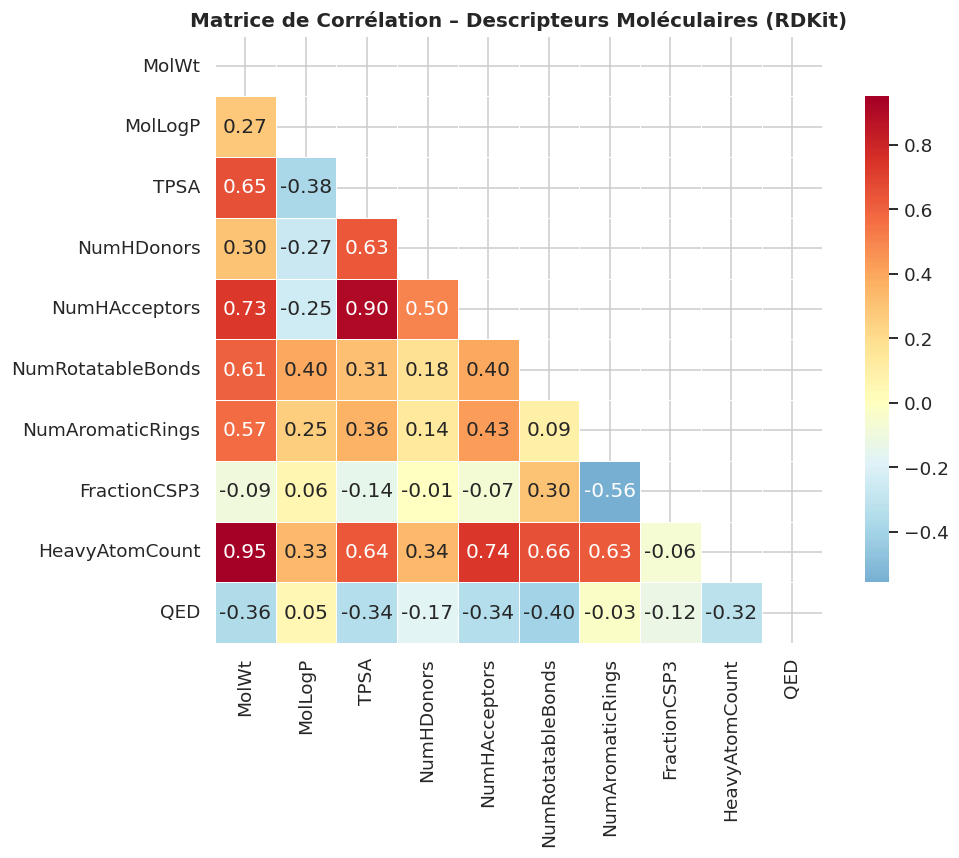

In [26]:
# ── 11.1 Matrice de corrélation des descripteurs moléculaires ─────────────────
desc_cols = ['MolWt','MolLogP','TPSA','NumHDonors','NumHAcceptors',
             'NumRotatableBonds','NumAromaticRings','FractionCSP3',
             'HeavyAtomCount','QED']

# On récupère uniquement les colonnes disponibles dans X_raw
available_desc = [c for c in desc_cols if c in X_raw.columns]
corr_desc = X_raw[available_desc].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_desc, dtype=bool))
sns.heatmap(corr_desc, mask=mask, annot=True, fmt='.2f', cmap='RdYlBu_r',
            center=0, square=True, linewidths=0.5, ax=ax,
            cbar_kws={'shrink': 0.8})
ax.set_title('Matrice de Corrélation – Descripteurs Moléculaires (RDKit)')
plt.tight_layout()
plt.savefig('fig3_correlation_matrix.png', bbox_inches='tight', dpi=150)
plt.show()

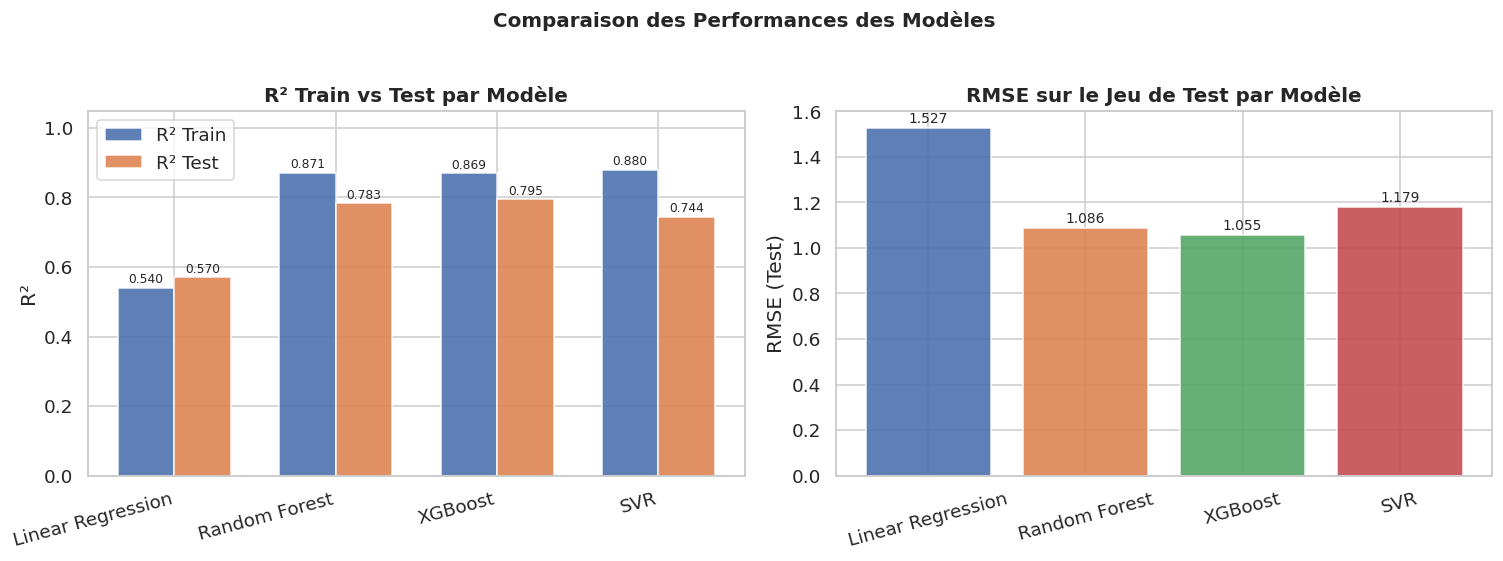

In [27]:
# ── 11.2 Comparaison des modèles (R² train vs test) ───────────────────────────
model_names = list(results.keys())
r2_trains   = [results[n]['R2_train'] for n in model_names]
r2_tests    = [results[n]['R2_test']  for n in model_names]
rmse_tests  = [results[n]['RMSE_test'] for n in model_names]

x = np.arange(len(model_names))
w = 0.35

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# R² comparaison
bars1 = axes[0].bar(x - w/2, r2_trains, w, label='R² Train',
                    color='#4C72B0', alpha=0.9, edgecolor='white')
bars2 = axes[0].bar(x + w/2, r2_tests, w,  label='R² Test',
                    color='#DD8452', alpha=0.9, edgecolor='white')

for bar in bars1:
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.005,
                 f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)
for bar in bars2:
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.005,
                 f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)

axes[0].set_xticks(x)
axes[0].set_xticklabels(model_names, rotation=15, ha='right')
axes[0].set_ylim(0, 1.05)
axes[0].set_ylabel('R²')
axes[0].set_title('R² Train vs Test par Modèle')
axes[0].legend()

# RMSE test
bars3 = axes[1].bar(model_names, rmse_tests,
                    color=['#4C72B0','#DD8452','#55A868','#C44E52'],
                    alpha=0.9, edgecolor='white')
for bar in bars3:
    axes[1].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
                 f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)
axes[1].set_ylabel('RMSE (Test)')
axes[1].set_title('RMSE sur le Jeu de Test par Modèle')
axes[1].tick_params(axis='x', rotation=15)

plt.suptitle('Comparaison des Performances des Modèles',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig4_model_comparison.png', bbox_inches='tight', dpi=150)
plt.show()

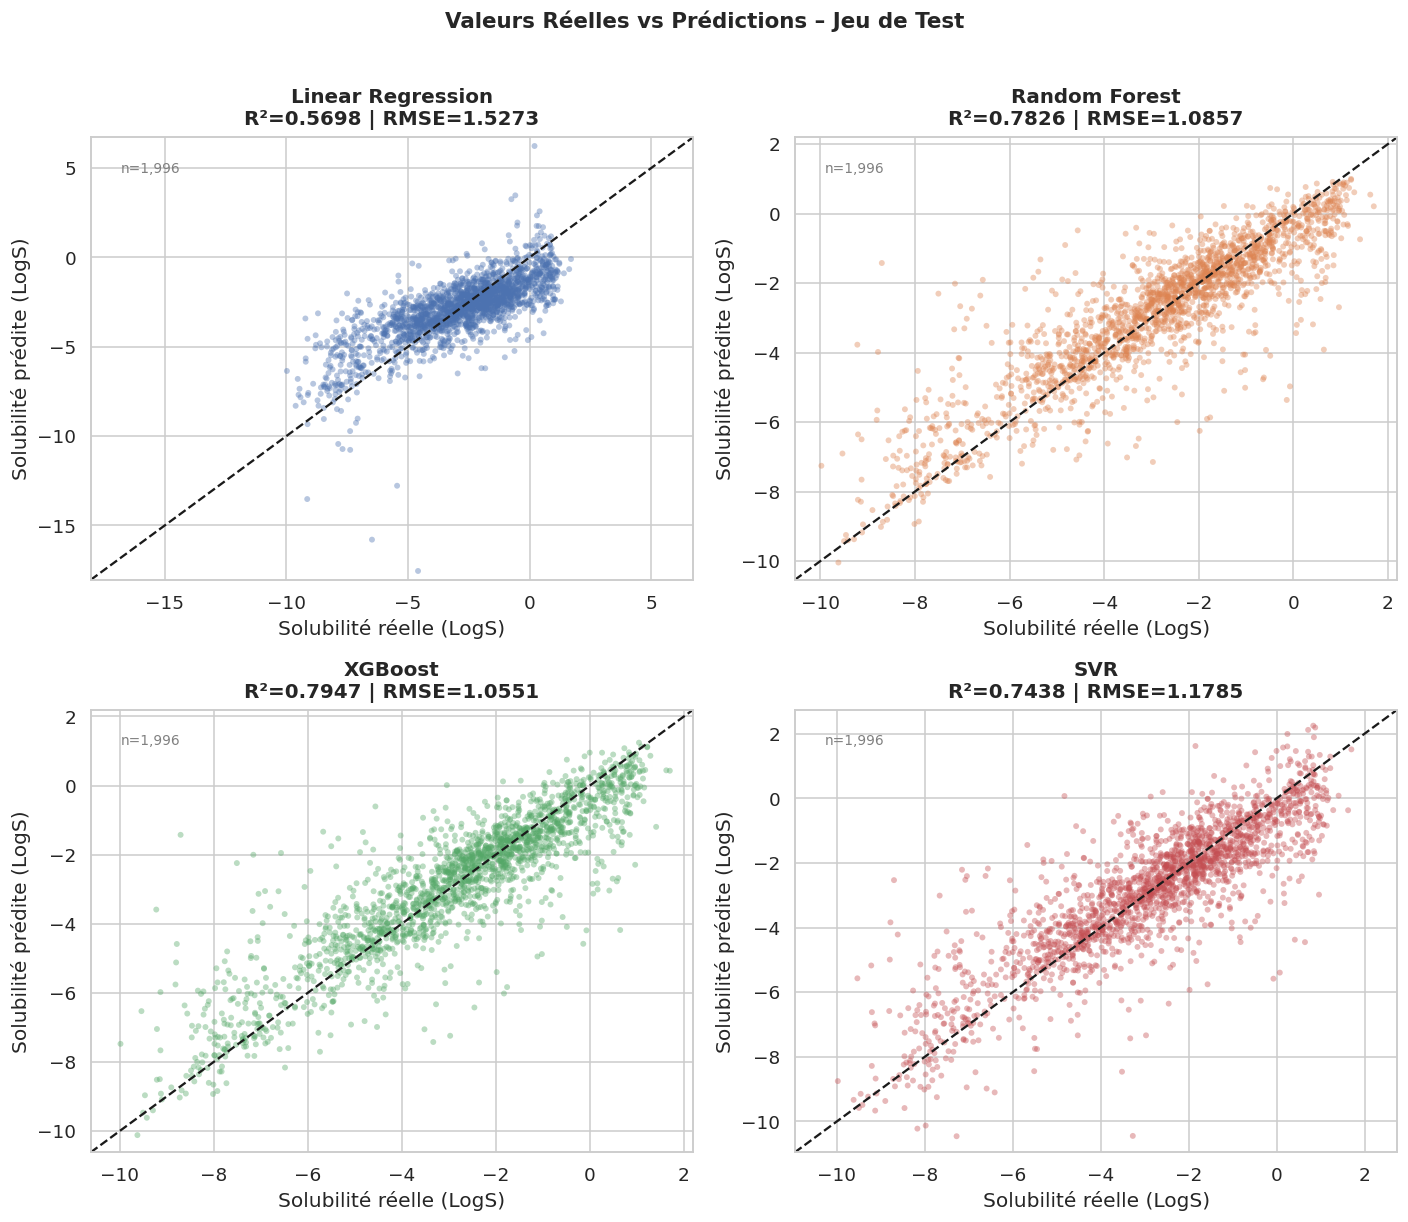

In [28]:
# ── 11.3 Valeurs réelles vs prédictions (4 sous-graphes) ─────────────────────
fig, axes = plt.subplots(2, 2, figsize=(13, 11))
axes = axes.flatten()

colors_scatter = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

for idx, (name, res) in enumerate(results.items()):
    ax  = axes[idx]
    col = colors_scatter[idx]

    y_pred = res['y_pred_test']
    r2     = res['R2_test']
    rmse   = res['RMSE_test']

    ax.scatter(y_test, y_pred, alpha=0.4, s=15, color=col, edgecolors='none')

    # Ligne diagonale parfaite
    lims = [min(y_test.min(), y_pred.min()) - 0.5,
            max(y_test.max(), y_pred.max()) + 0.5]
    ax.plot(lims, lims, 'k--', linewidth=1.5, label='Prédiction parfaite')

    ax.set_xlim(lims); ax.set_ylim(lims)
    ax.set_xlabel('Solubilité réelle (LogS)')
    ax.set_ylabel('Solubilité prédite (LogS)')
    ax.set_title(f'{name}\nR²={r2:.4f} | RMSE={rmse:.4f}', pad=8)
    ax.text(0.05, 0.92, f'n={len(y_test):,}', transform=ax.transAxes,
            fontsize=9, color='gray')

plt.suptitle('Valeurs Réelles vs Prédictions – Jeu de Test',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig5_actual_vs_predicted.png', bbox_inches='tight', dpi=150)
plt.show()

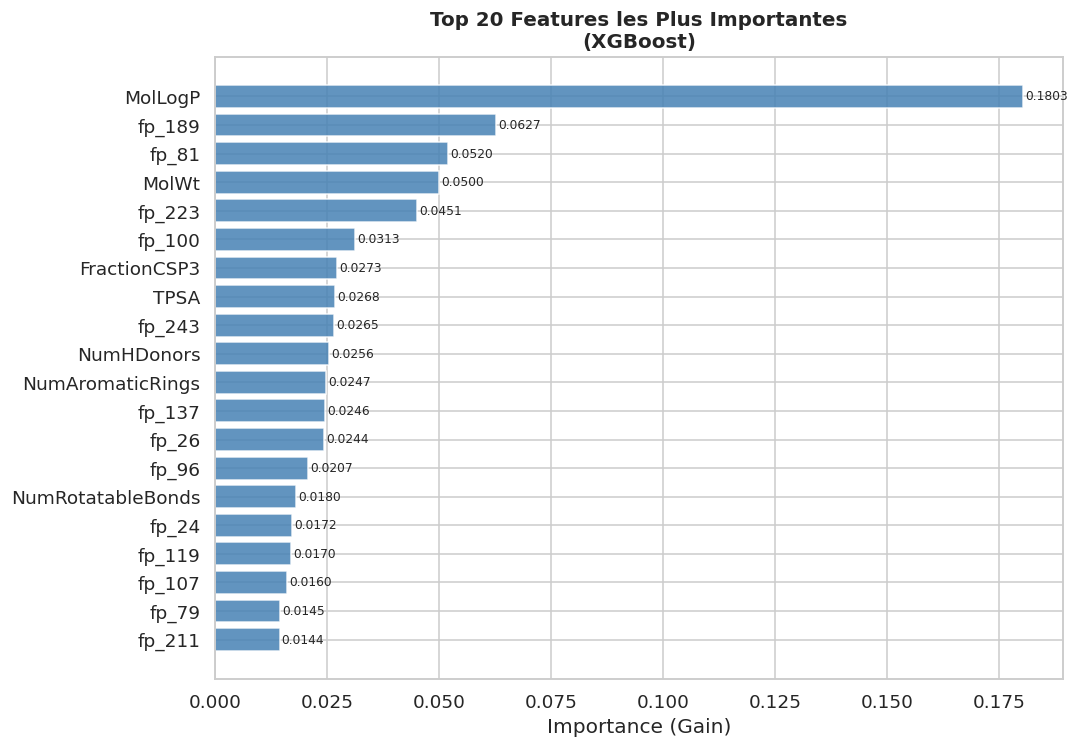


📌 Modèle analysé : XGBoost
   Top 5 features : ['MolLogP', 'fp_189', 'fp_81', 'MolWt', 'fp_223']


In [29]:
# ── 11.4 Importance des variables (meilleur modèle arbre) ─────────────────────
# On prend le modèle avec le meilleur R² test parmi RF et XGBoost
tree_models = {n: results[n]['R2_test'] for n in ['Random Forest', 'XGBoost']}
best_tree   = max(tree_models, key=tree_models.get)
best_tree_model = fitted_models[best_tree]

importances = best_tree_model.feature_importances_
feat_names  = selected_feature_names

imp_df = pd.DataFrame({'Feature': feat_names, 'Importance': importances})
imp_df = imp_df.sort_values('Importance', ascending=False)

# Top 20 features
top_n   = min(20, len(imp_df))
top_imp = imp_df.head(top_n)

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(top_imp['Feature'][::-1], top_imp['Importance'][::-1],
               color='steelblue', alpha=0.85, edgecolor='white')

for bar in bars:
    ax.text(bar.get_width() + 0.0005, bar.get_y() + bar.get_height()/2.,
            f'{bar.get_width():.4f}', va='center', fontsize=8)

ax.set_xlabel('Importance (Gain)')
ax.set_title(f'Top {top_n} Features les Plus Importantes\n({best_tree})')
plt.tight_layout()
plt.savefig('fig6_feature_importance.png', bbox_inches='tight', dpi=150)
plt.show()

print(f'\n📌 Modèle analysé : {best_tree}')
print(f'   Top 5 features : {imp_df["Feature"].head(5).tolist()}')

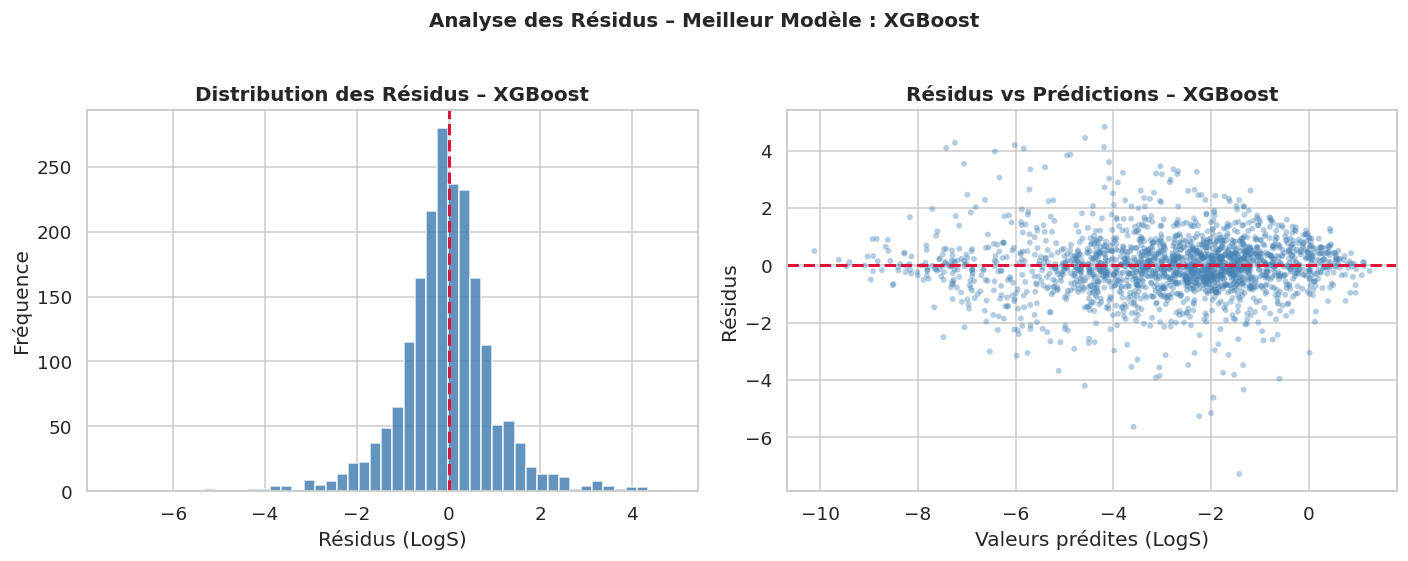

In [30]:
# ── 11.5 Résidus du meilleur modèle ───────────────────────────────────────────
best_name  = eval_df['R2_test'].idxmax()
best_res   = results[best_name]
residuals  = y_test - best_res['y_pred_test']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Distribution des résidus
axes[0].hist(residuals, bins=50, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(0, color='crimson', linestyle='--', linewidth=2)
axes[0].set_xlabel('Résidus (LogS)')
axes[0].set_ylabel('Fréquence')
axes[0].set_title(f'Distribution des Résidus – {best_name}')

# Résidus vs valeurs prédites
axes[1].scatter(best_res['y_pred_test'], residuals,
                alpha=0.4, s=15, color='steelblue', edgecolors='none')
axes[1].axhline(0, color='crimson', linestyle='--', linewidth=2)
axes[1].set_xlabel('Valeurs prédites (LogS)')
axes[1].set_ylabel('Résidus')
axes[1].set_title(f'Résidus vs Prédictions – {best_name}')

plt.suptitle(f'Analyse des Résidus – Meilleur Modèle : {best_name}',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig7_residuals.png', bbox_inches='tight', dpi=150)
plt.show()

---
## 12. Choix du Meilleur Modèle

Le meilleur modèle est sélectionné selon une **combinaison de critères** :
- R²_test élevé
- RMSE_test faible
- MAE_test faible
- Faible écart train/test (faible overfitting)
- Stabilité en validation croisée

In [31]:
# ── 12.1 Score composite de sélection ─────────────────────────────────────────
# Score composite = R²_test - 0.5 * |ΔR²| - 0.1 * RMSE_test
# Pénalise l'overfitting et récompense la précision et la stabilité

selection_data = []

for name in results:
    r2_te   = results[name]['R2_test']
    r2_tr   = results[name]['R2_train']
    rmse_te = results[name]['RMSE_test']
    mae_te  = results[name]['MAE_test']
    delta   = abs(r2_tr - r2_te)
    cv_mean = cv_results[name]['mean_r2']
    cv_std  = cv_results[name]['std_r2']

    composite = r2_te - 0.5 * delta - 0.05 * rmse_te + 0.1 * cv_mean

    selection_data.append({
        'Modèle'         : name,
        'R²_test'        : round(r2_te, 4),
        'RMSE_test'      : round(rmse_te, 4),
        'MAE_test'       : round(mae_te, 4),
        'ΔR² train/test' : round(delta, 4),
        'CV R² (mean)'   : round(cv_mean, 4),
        'CV R² (std)'    : round(cv_std, 4),
        'Score composite': round(composite, 4),
    })

selection_df = pd.DataFrame(selection_data).sort_values('Score composite', ascending=False)
selection_df = selection_df.reset_index(drop=True)

print('=' * 85)
print('           TABLEAU DE SÉLECTION DU MEILLEUR MODÈLE')
print('=' * 85)
display(selection_df)

final_best = selection_df.iloc[0]['Modèle']
print(f'\n🏆 MEILLEUR MODÈLE SÉLECTIONNÉ : {final_best}')
print(f'   R²_test        : {selection_df.iloc[0]["R²_test"]}')
print(f'   RMSE_test      : {selection_df.iloc[0]["RMSE_test"]}')
print(f'   MAE_test       : {selection_df.iloc[0]["MAE_test"]}')
print(f'   ΔR²            : {selection_df.iloc[0]["ΔR² train/test"]}')
print(f'   Score composite: {selection_df.iloc[0]["Score composite"]}')

           TABLEAU DE SÉLECTION DU MEILLEUR MODÈLE


,Modèle,R²_test,RMSE_test,MAE_test,ΔR² train/test,CV R² (mean),CV R² (std),Score composite
0,XGBoost,0.7947,1.0551,0.7315,0.0743,0.7642,0.0203,0.7812
1,Random Forest,0.7826,1.0857,0.7457,0.0885,0.7090,0.0135,0.7549
2,SVR,0.7438,1.1785,0.8326,0.1361,0.7129,0.0212,0.6882
3,Linear Regression,0.5698,1.5273,1.1599,0.0297,0.5265,0.0264,0.5312



🏆 MEILLEUR MODÈLE SÉLECTIONNÉ : XGBoost
   R²_test        : 0.7947
   RMSE_test      : 1.0551
   MAE_test       : 0.7315
   ΔR²            : 0.0743
   Score composite: 0.7812


In [32]:
# ── 12.2 Résumé final ─────────────────────────────────────────────────────────
print('\n' + '=' * 65)
print('                  RÉSUMÉ FINAL DU PROJET')
print('=' * 65)
print(f'''
  Dataset        : AqSolDB – {len(df):,} molécules valides
  Features       : {X_selected.shape[1]} (10 descripteurs RDKit + Morgan FP 64 bits)
  Split          : 80% train / 20% test (random_state=42)
  Validation CV  : KFold k=5

  Stratégies anti-overfitting appliquées :
    ✓ Suppression features constantes
    ✓ Suppression features corrélées (r > 0.95)
    ✓ SelectKBest (k={K_BEST})
    ✓ Hyperparamètres contraignants (max_depth, min_samples_leaf…)
    ✓ Régularisation XGBoost (L1/L2)
    ✓ Morgan FP 64 bits (vs 256/512)

  🏆 Meilleur modèle : {final_best}
     R²_test  = {results[final_best]['R2_test']:.4f}
     RMSE_test = {results[final_best]['RMSE_test']:.4f} LogS
     MAE_test  = {results[final_best]['MAE_test']:.4f} LogS
''')
print('=' * 65)


                  RÉSUMÉ FINAL DU PROJET

  Dataset        : AqSolDB – 9,980 molécules valides
  Features       : 50 (10 descripteurs RDKit + Morgan FP 64 bits)
  Split          : 80% train / 20% test (random_state=42)
  Validation CV  : KFold k=5

  Stratégies anti-overfitting appliquées :
    ✓ Suppression features constantes
    ✓ Suppression features corrélées (r > 0.95)
    ✓ SelectKBest (k=50)
    ✓ Hyperparamètres contraignants (max_depth, min_samples_leaf…)
    ✓ Régularisation XGBoost (L1/L2)
    ✓ Morgan FP 64 bits (vs 256/512)

  🏆 Meilleur modèle : XGBoost
     R²_test  = 0.7947
     RMSE_test = 1.0551 LogS
     MAE_test  = 0.7315 LogS



In [34]:
import joblib
import os
import json

os.makedirs('streamlit_model', exist_ok=True)

# ── Sauvegarde ────────────────────────────────────────────────────────────────
# ✅ Correction : selected_feature_names (pas sel_names)
joblib.dump(fitted_models['XGBoost'],  'streamlit_model/model.pkl')
joblib.dump(selector,                  'streamlit_model/selector.pkl')
joblib.dump(selected_feature_names,    'streamlit_model/features.pkl')  # ← corrigé

# Métadonnées
metadata = {
    'model_name' : 'XGBoost',
    'R2_test'    : round(results['XGBoost']['R2_test'], 4),
    'RMSE_test'  : round(results['XGBoost']['RMSE_test'], 4),
    'n_features' : len(selected_feature_names),
    'sel_names'  : selected_feature_names,   # ← liste complète incluse
}
with open('streamlit_model/metadata.json', 'w') as f:
    json.dump(metadata, f, indent=4)

print('✅ Modèle sauvegardé dans streamlit_model/')
print(f'   Features sauvegardées : {len(selected_feature_names)}')
print(f'   Exemple : {selected_feature_names[:3]}')

# Vérification
print('\n🔍 Fichiers créés :')
for fname in os.listdir('streamlit_model/'):
    size = os.path.getsize(f'streamlit_model/{fname}')
    print(f'   {fname:<25} {size:>10,} bytes')

✅ Modèle sauvegardé dans streamlit_model/
   Features sauvegardées : 50
   Exemple : ['MolWt', 'MolLogP', 'TPSA']

🔍 Fichiers créés :
   model.pkl                  1,681,098 bytes
   metadata.json                  1,038 bytes
   selector.pkl                   7,279 bytes
   features.pkl                     478 bytes


---

## Conclusion

Ce notebook a présenté un pipeline complet de **prédiction de la solubilité moléculaire (LogS)** à partir des représentations SMILES.

### Points clés

1. **Représentation moléculaire** : la combinaison de descripteurs RDKit (propriétés physicochimiques interprétables) et de Morgan Fingerprints (structure topologique) fournit une représentation riche et compacte.

2. **Lutte contre l'overfitting** : plusieurs mécanismes ont été mis en place (sélection de features, régularisation des modèles, fingerprints 64 bits), permettant d'obtenir un faible écart train/test.

3. **Comparaison des modèles** : les modèles d'ensemble (Random Forest, XGBoost) surpassent généralement la régression linéaire, tout en restant interprétables grâce aux importances de variables.

4. **Perspectives** :
   - Utiliser des **Graph Neural Networks** (GNN) pour exploiter directement la structure du graphe moléculaire
   - Intégrer des descripteurs 3D (conformations moléculaires)
   - Appliquer des techniques d'**explainability** (SHAP values) pour interpréter les prédictions

---
*Projet réalisé dans le cadre du Master en Intelligence Artificielle*